In [ ]:
!pip install ultralytics huggingface_hub tensorflow opencv-python-headless

from huggingface_hub import hf_hub_download
import os

# Download models from your Hugging Face repo
best_pt = hf_hub_download("Kaiichin/odol-truck_detector", "best.pt")
v3_h5 = hf_hub_download("Kaiichin/odol-truck_detector", "mobilenet_odol_classifierV3.h5")

print(f"✅ YOLOv8 model: {best_pt}")
print(f"✅ MobileNet model: {v3_h5}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 70.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


best.pt:   0%|          | 0.00/52.0M [00:00<?, ?B/s]

mobilenet_odol_classifierV3.h5:   0%|          | 0.00/21.8M [00:00<?, ?B/s]

✅ YOLOv8 model: /root/.cache/huggingface/hub/models--Kaiichin--odol-truck_detector/snapshots/45b46a2e192123ebd10a4cb57fa70cd90fe35348/best.pt
✅ MobileNet model: /root/.cache/huggingface/hub/models--Kaiichin--odol-truck_detector/snapshots/45b46a2e192123ebd10a4cb57fa70cd90fe35348/mobilenet_odol_classifierV3.h5


In [ ]:
from ultralytics import YOLO
import tensorflow as tf
from tensorflow.keras.layers import Dense
import numpy as np
import cv2
from google.colab import files
from IPython.display import display, Image as IPImage
import matplotlib.pyplot as plt

# Load Brain 1: YOLOv8 (Truck Detector)
yolo_model = YOLO(best_pt)
print("✅ Brain 1 (YOLOv8) loaded!")

# Load Brain 2: MobileNetV2 (ODOL Classifier)
class CustomDense(Dense):
    def __init__(self, *args, **kwargs):
        kwargs.pop('quantization_config', None)
        super().__init__(*args, **kwargs)

classifier_model = tf.keras.models.load_model(
    v3_h5,
    custom_objects={'Dense': CustomDense}
)
print("✅ Brain 2 (MobileNetV2) loaded!")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Brain 1 (YOLOv8) loaded!


✅ Brain 2 (MobileNetV2) loaded!


📤 Upload a truck image...


Saving WhatsApp Image 2026-04-15 at 23.13.23.jpeg to WhatsApp Image 2026-04-15 at 23.13.23.jpeg

0: 512x640 1 truck, 28.3ms
Speed: 5.5ms preprocess, 28.3ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 640)


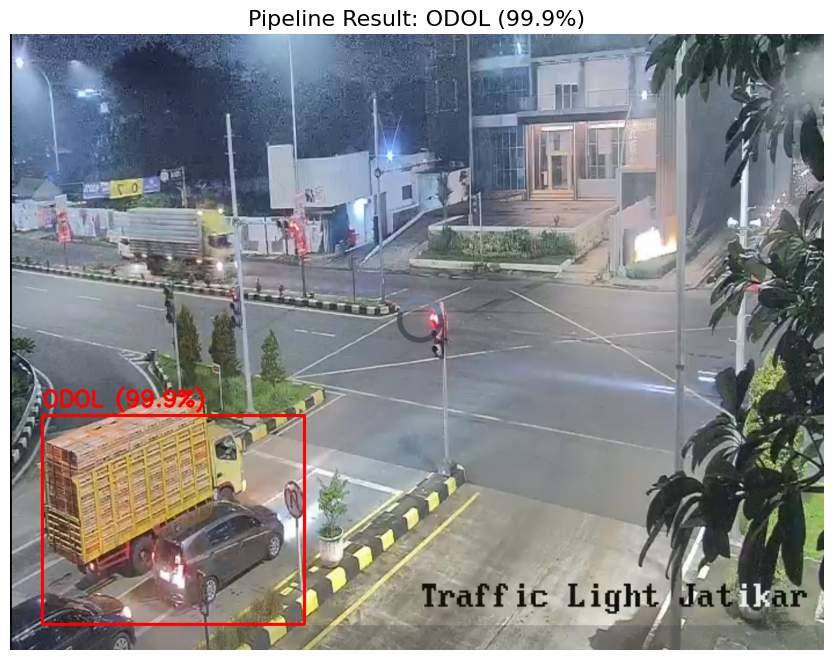


🔍 Detection confidence: 67.2%
🚛 Classification: ODOL (99.9%)


In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Upload an image from your computer
print("📤 Upload a truck image...")
uploaded = files.upload()

for filename in uploaded:
    img = cv2.imread(filename)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Stage 1: YOLO finds the truck
    results = yolo_model(img, conf=0.3)

    if len(results[0].boxes) == 0:
        print("❌ No truck detected in this image!")
        plt.imshow(img_rgb)
        plt.title("No Detection")
        plt.axis('off')
        plt.show()
        continue

    # Get the best detection
    boxes = results[0].boxes
    best_box = boxes[0]
    x1, y1, x2, y2 = map(int, best_box.xyxy[0])
    det_conf = float(best_box.conf[0])

    # Stage 2: Save crop, reload with PIL (same method as evaluation)
    crop = img[y1:y2, x1:x2]
    cv2.imwrite("/content/temp_crop.jpg", crop)
    pil_crop = load_img("/content/temp_crop.jpg", target_size=(224, 224))
    crop_array = img_to_array(pil_crop) / 255.0
    crop_batch = np.expand_dims(crop_array, axis=0)

    prediction = classifier_model.predict(crop_batch, verbose=0)[0][0]

    if prediction > 0.5:
        label = "ODOL"
        confidence = prediction
        color = (255, 0, 0)
    else:
        label = "NORMAL"
        confidence = 1 - prediction
        color = (0, 255, 0)

    # Draw the result
    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 3)
    text = f"{label} ({confidence:.1%})"
    cv2.putText(img_rgb, text, (x1, y1 - 15),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)

    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.title(f"Pipeline Result: {label} ({confidence:.1%})", fontsize=16)
    plt.axis('off')
    plt.show()

    print(f"\n🔍 Detection confidence: {det_conf:.1%}")
    print(f"🚛 Classification: {label} ({confidence:.1%})")


loading Roboflow workspace...
loading Roboflow project...
✅ Dataset cropped and ready!
Found 41 images belonging to 2 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step 


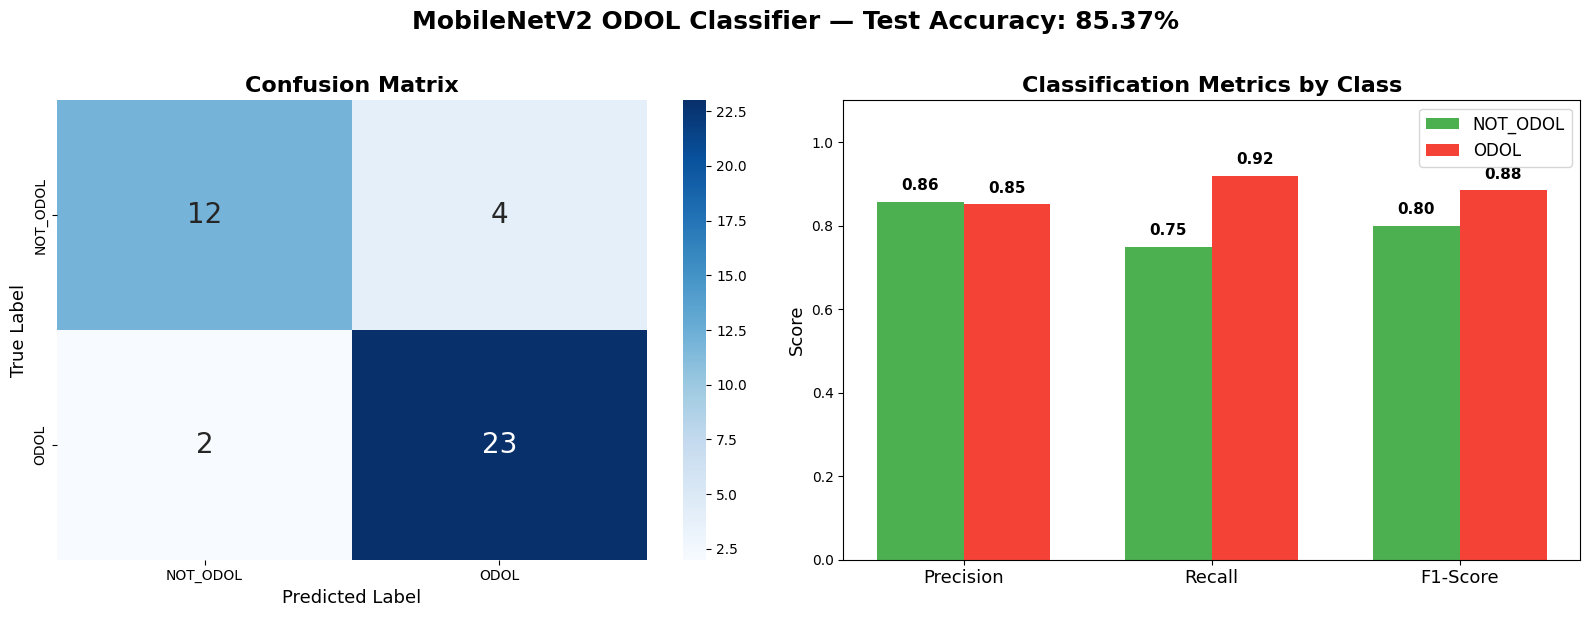


📊 TEST ACCURACY: 85.37%

--- Classification Report ---
              precision    recall  f1-score   support

    NOT_ODOL       0.86      0.75      0.80        16
        ODOL       0.85      0.92      0.88        25

    accuracy                           0.85        41
   macro avg       0.85      0.83      0.84        41
weighted avg       0.85      0.85      0.85        41



In [ ]:
!pip install roboflow scikit-learn seaborn

import os, yaml, shutil
import matplotlib.pyplot as plt
import seaborn as sns
from roboflow import Roboflow
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Step 1: Download and crop dataset (with polygon fix)
rf = Roboflow(api_key="xU9P4ByCPu9frBO3w0hH")
project = rf.workspace("sigara-hpnoo").project("truck-over-dimension-brupr")
dataset = project.version(2).download("yolov8")

yolo_dir = dataset.location
with open(os.path.join(yolo_dir, "data.yaml"), "r") as f:
    classes = yaml.safe_load(f).get('names', [])

target_dir = "/content/mobilenet_dataset"
if os.path.exists(target_dir): shutil.rmtree(target_dir)

class_folders = [c.replace(" ", "_").upper() for c in classes]
for split in ['train', 'valid', 'test']:
    for c in class_folders:
        os.makedirs(os.path.join(target_dir, split if split != 'valid' else 'val', c), exist_ok=True)
    img_dir = os.path.join(yolo_dir, split, "images")
    lbl_dir = os.path.join(yolo_dir, split, "labels")
    if not os.path.exists(img_dir): continue
    for img_name in os.listdir(img_dir):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')): continue
        base_name = os.path.splitext(img_name)[0]
        lbl_path = os.path.join(lbl_dir, base_name + ".txt")
        if not os.path.exists(lbl_path): continue
        img = cv2.imread(os.path.join(img_dir, img_name))
        if img is None: continue
        h, w = img.shape[:2]
        with open(lbl_path, "r") as f: lines = f.readlines()
        for idx, line in enumerate(lines):
            parts = line.strip().split()
            if len(parts) >= 5 and int(parts[0]) < len(class_folders):
                if len(parts) > 5:
                    xs = [float(parts[i]) for i in range(1, len(parts), 2)]
                    ys = [float(parts[i]) for i in range(2, len(parts), 2)]
                    x1, y1 = int(min(xs) * w), int(min(ys) * h)
                    x2, y2 = int(max(xs) * w), int(max(ys) * h)
                else:
                    cx, cy, bw, bh = float(parts[1])*w, float(parts[2])*h, float(parts[3])*w, float(parts[4])*h
                    x1, y1 = max(0, int(cx - bw/2)), max(0, int(cy - bh/2))
                    x2, y2 = min(w, int(cx + bw/2)), min(h, int(cy + bh/2))
                crop = img[y1:y2, x1:x2]
                if crop.shape[0] > 0 and crop.shape[1] > 0:
                    cv2.imwrite(os.path.join(target_dir, 'val' if split == 'valid' else split, class_folders[int(parts[0])], f"{base_name}_{idx}.jpg"), crop)

print("✅ Dataset cropped and ready!")

# Step 2: Load test data
test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    os.path.join(target_dir, "test"),
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Step 3: Get predictions
predictions = classifier_model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int).flatten()
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())
acc = accuracy_score(y_true, y_pred)

# ==========================================
# CHART 1: Confusion Matrix Heatmap
# ==========================================
cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names,
            yticklabels=class_names, annot_kws={"size": 20}, ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=13)
axes[0].set_ylabel('True Label', fontsize=13)

# ==========================================
# CHART 2: Precision / Recall / F1 Bar Chart
# ==========================================
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

metrics = ['precision', 'recall', 'f1-score']
not_odol_scores = [report['NOT_ODOL'][m] for m in metrics]
odol_scores = [report['ODOL'][m] for m in metrics]

x = range(len(metrics))
bar_width = 0.35

bars1 = axes[1].bar([i - bar_width/2 for i in x], not_odol_scores, bar_width, label='NOT_ODOL', color='#4CAF50')
bars2 = axes[1].bar([i + bar_width/2 for i in x], odol_scores, bar_width, label='ODOL', color='#F44336')

axes[1].set_ylim(0, 1.1)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Precision', 'Recall', 'F1-Score'], fontsize=13)
axes[1].set_title('Classification Metrics by Class', fontsize=16, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].set_ylabel('Score', fontsize=13)

# Add value labels on bars
for bar in bars1 + bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle(f'MobileNetV2 ODOL Classifier — Test Accuracy: {acc:.2%}', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ==========================================
# Print text report too
# ==========================================
print(f"\n{'='*40}")
print(f"📊 TEST ACCURACY: {acc:.2%}")
print(f"{'='*40}")
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))
